In [1]:
%%configure -f
{
  "conf": {
    "spark.pyspark.virtualenv.enabled": "true",
    "spark.pyspark.virtualenv.bin.path": "/usr/bin/virtualenv",
    "spark.pyspark.virtualenv.type": "native",
    "spark.pyspark.python": "/usr/bin/python3",
    "spark.executorEnv.PYSPARK_PYTHON": "/usr/bin/python3"
  }
}

ID,YARN Application ID,Kind,State,Spark UI,Driver log,User,Current session?
0,application_1780100949250_0001,pyspark,idle,Link,Link,None,


In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("kMeansClustering").getOrCreate()

df = spark.read.csv("s3://csc555-emr-studio-lmedina/HW5/chicago_cca.csv", 
                    header=True, inferSchema=True)

df2 = df.select("black", "hispanic", "unemp", "income")
df2.show(5)

VBox()

Starting Spark application


ID,YARN Application ID,Kind,State,Spark UI,Driver log,User,Current session?
5,application_1780100949250_0006,pyspark,idle,Link,Link,None,✔


FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

SparkSession available as 'spark'.


FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+------+--------+------+------+
| black|hispanic| unemp|income|
+------+--------+------+------+
|0.2602|  0.2458|0.0934| 54765|
|0.1047|  0.1792|0.0997| 88476|
|0.1995|  0.1288|0.1009| 69333|
|0.0386|  0.1577| 0.079| 84750|
|0.0171|  0.1384|0.0459|132500|
+------+--------+------+------+
only showing top 5 rows

In [3]:
spark.sparkContext.install_pypi_package("numpy")
spark.sparkContext.install_pypi_package("matplotlib")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…



ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas 2.3.3 requires tzdata>=2022.7, which is not installed.
matplotlib 3.9.4 requires contourpy>=1.0.1, which is not installed.
matplotlib 3.9.4 requires cycler>=0.10, which is not installed.
matplotlib 3.9.4 requires fonttools>=4.22.0, which is not installed.
matplotlib 3.9.4 requires importlib-resources>=3.2.0; python_version < "3.10", which is not installed.
matplotlib 3.9.4 requires kiwisolver>=1.3.1, which is not installed.
matplotlib 3.9.4 requires pillow>=8, which is not installed.
pandas 2.3.3 requires python-dateutil>=2.8.2, but you have python-dateutil 2.8.1 which is incompatible.


In [4]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans

assembler = VectorAssembler(inputCols=["black", "hispanic", "unemp", "income"],
                            outputCol="features", handleInvalid="skip")

df_assembled = assembler.transform(df2)

kmeans = KMeans(k=3, seed=42)
model = kmeans.fit(df_assembled)

predictions = model.transform(df_assembled)
predictions.show(5)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+------+--------+------+------+--------------------+----------+
| black|hispanic| unemp|income|            features|prediction|
+------+--------+------+------+--------------------+----------+
|0.2602|  0.2458|0.0934| 54765|[0.2602,0.2458,0....|         1|
|0.1047|  0.1792|0.0997| 88476|[0.1047,0.1792,0....|         0|
|0.1995|  0.1288|0.1009| 69333|[0.1995,0.1288,0....|         0|
|0.0386|  0.1577| 0.079| 84750|[0.0386,0.1577,0....|         0|
|0.0171|  0.1384|0.0459|132500|[0.0171,0.1384,0....|         2|
+------+--------+------+------+--------------------+----------+
only showing top 5 rows

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

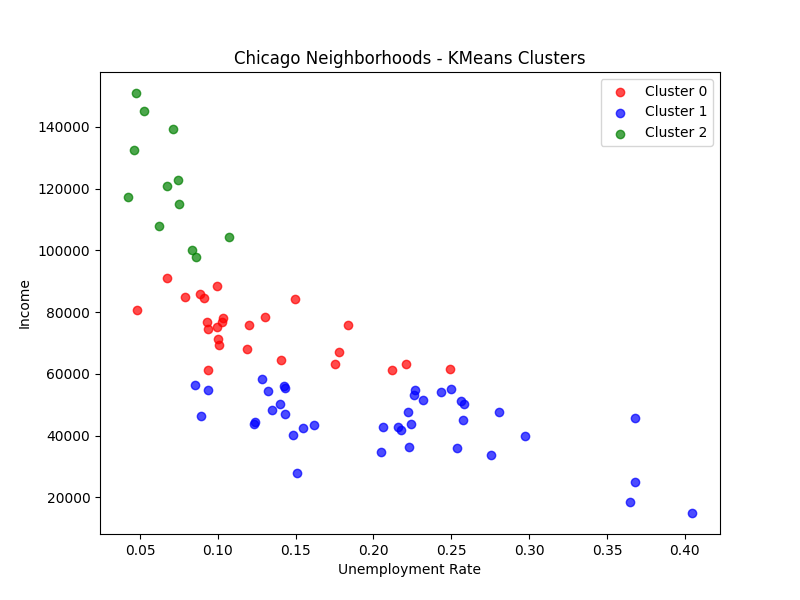

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

pdf = predictions.select("unemp", "income", "prediction").toPandas()

colors = {0: "red", 1: "blue", 2: "green"}
plt.figure(figsize=(8,6))
for cluster in [0, 1, 2]:
    subset = pdf[pdf["prediction"] == cluster]
    plt.scatter(subset["unemp"], subset["income"], 
                c=colors[cluster], label=f"Cluster {cluster}", alpha=0.7)

plt.xlabel("Unemployment Rate")
plt.ylabel("Income")
plt.title("Chicago Neighborhoods - KMeans Clusters")
plt.legend()
%matplot plt

In [6]:
predictions.groupBy("prediction").avg("black", "hispanic", "unemp", "income")\
    .orderBy("prediction").show()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+----------+-------------------+-------------------+------------------+------------------+
|prediction|         avg(black)|      avg(hispanic)|        avg(unemp)|       avg(income)|
+----------+-------------------+-------------------+------------------+------------------+
|         0|           0.239236|0.27587999999999996|          0.125572|          74462.36|
|         1| 0.5462743589743589| 0.2950999999999999|0.2094743589743589|44494.769230769234|
|         2|0.12221666666666668|0.12960833333333333|          0.067875|121238.08333333333|
+----------+-------------------+-------------------+------------------+------------------+

In [7]:
#done

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…